                                           filename  width  height     class  \
0  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   
1  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256  Fillings   
2  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   
3  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   
4  0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg    512     256   Implant   

   xmin  ymin  xmax  ymax  
0   175   116   206   153  
1   170   109   189   133  
2   221   124   257   178  
3   302   126   329   175  
4   335   114   360   154  


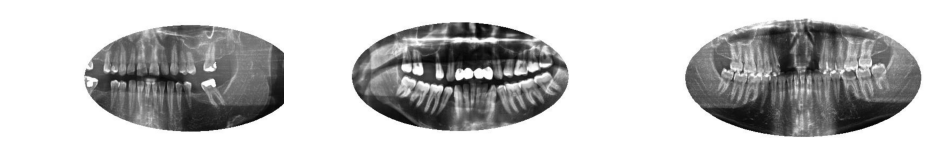

Working directory changed to: /kaggle/working


In [5]:
# تثبيت YOLOv8
!pip install ultralytics

# استيراد المكتبات
import numpy as np
import pandas as pd
import os
import cv2 as cv
import matplotlib.pyplot as plt
import warnings
from ultralytics import YOLO  # استيراد YOLOv8 بعد التثبيت

warnings.filterwarnings("ignore")

# تحميل بيانات التدريب
data_path = "/kaggle/input/dental-radiography/train/_annotations.csv"
data = pd.read_csv(data_path)
print(data.head())

# عرض بعض الصور من مجموعة البيانات
image_paths = [
    "/kaggle/input/yolo-penaromic-xray/test/test/images/0004_jpg.rf.6434bfce7667ea786e5f251dc0d8b8b1.jpg",
    "/kaggle/input/yolo-penaromic-xray/train/train/images/0001_jpg.rf.30a42966fb9c51553f6949b70234218d.jpg",
    "/kaggle/input/yolo-penaromic-xray/valid/valid/images/0003_jpg.rf.ca9d51a22c825737b49a5f73d3172d23.jpg"
]

fig, ax = plt.subplots(1, len(image_paths), figsize=(12, 6))

for i, path in enumerate(image_paths):
    image = cv.imread(path)
    image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    ax[i].imshow(image)
    ax[i].axis("off")  # إخفاء المحاور

plt.show()

# تحديد مسار العمل إلى مجلد Kaggle
os.chdir("/kaggle/working/")
print(f"Working directory changed to: {os.getcwd()}")


In [6]:
# Install YOLOv8
!pip install -q ultralytics

import os
import yaml
from ultralytics import YOLO  

# Copy dataset to the working directory
!cp -r /kaggle/input/yolo-penaromic-xray/train/train /kaggle/working/
!cp -r /kaggle/input/yolo-penaromic-xray/test/test /kaggle/working/
!cp -r /kaggle/input/yolo-penaromic-xray/valid/valid /kaggle/working/

# Create .yaml file for YOLOv8
data_yaml = dict(
    path='/kaggle/working/',  
    train='train',  
    val='valid',    
    test='test',    
    nc=4,  
    names=['Implant', 'Fillings', 'Impacted Tooth', 'Cavity']  
)

# Save YAML file
yaml_path = '/kaggle/working/data.yaml'
with open(yaml_path, 'w') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=False)

print(f"Dataset YAML file created successfully at: {yaml_path}")


Dataset YAML file created successfully at: /kaggle/working/data.yaml


In [9]:
import torch
from ultralytics import YOLO

# تحميل النموذج المدرب مسبقًا أو البدء من الصفر
model = YOLO('yolov8x.yaml')  # استخدم 'yolov8x.pt' إذا كنت تريد تحميل الأوزان المدربة مسبقًا

# بدء عملية التدريب مع تحسين الإعدادات
model.train(
    data='data.yaml',
    epochs=150,  # زيادة عدد التكرارات لتحسين التدريب
    imgsz=640,  # حجم الصورة أثناء التدريب
    batch=16,  # حجم الدفعة (زيادة إذا كان الـ GPU يسمح بذلك)
    
    # تحسين Augmentation لزيادة تنوع البيانات
    mosaic=1.0,  # تعزيز الدمج بين الصور
    mixup=0.3,   # تحسين المزج مع تقليل القيمة لمنع التشويش الزائد
    auto_augment='randaugment',  # تحسين التعديلات التلقائية
    
    # تحسين تعديل الألوان
    hsv_h=0.02, hsv_s=0.75, hsv_v=0.5,
    
    # تحسين التحولات الهندسية
    degrees=7, translate=0.2, scale=0.4, shear=3.0,
    perspective=0.0015, flipud=0.02, fliplr=0.6,
    
    # تمكين التخزين المؤقت لتسريع التدريب
    cache=True,
    
    # تحسين استراتيجيات التدريب
    patience=50,  # زيادة الصبر لتجنب التوقف المبكر
    cos_lr=True,  # استخدام Cosine Annealing لمعدل التعلم
    warmup_epochs=10,  # زيادة فترة Warmup لمنح النموذج بداية أفضل
    optimizer='AdamW',  # تحسين الاستقرار باستخدام AdamW
    
    # تحسين ضبط الخسائر
    box=0.05, cls=0.5, kobj=1.0,  # ضبط وزن الخسائر لتحسين الدقة
    
    # استخدام GPU إذا كان متاحًا
    device='cuda' if torch.cuda.is_available() else 'cpu',
    
    # تفعيل التقييم بعد كل Epoch
    val=True,
    verbose=True,
    save=True
)


Ultralytics 8.3.81 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolov8x.yaml, data=data.yaml, epochs=150, time=None, patience=50, batch=16, imgsz=640, save=True, save_period=-1, cache=True, device=cuda, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, lin

100%|██████████| 755k/755k [00:00<00:00, 17.7MB/s]
2025-03-01 18:55:51,349	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-03-01 18:55:52,078	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1      2320  ultralytics.nn.modules.conv.Conv             [3, 80, 3, 2]                 
  1                  -1  1    115520  ultralytics.nn.modules.conv.Conv             [80, 160, 3, 2]               
  2                  -1  3    436800  ultralytics.nn.modules.block.C2f             [160, 160, 3, True]           
  3                  -1  1    461440  ultralytics.nn.modules.conv.Conv             [160, 320, 3, 2]              
  4                  -1  6   3281920  ultralytics.nn.modules.block.C2f             [320, 320, 6, True]           
  5                  -1  1   1844480  ultralytics.nn.modules.conv.Conv             [320, 640, 3, 2]              
  6                  -1  6  13117440  ultralytics.nn.modules.block.C2f             [640, 640, 6, True]           
  7                  -1  1   3687680  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 74.3MB/s]


AMP: checks passed ✅


...

                   all        121        780      0.779      0.774      0.818      0.495



150 epochs completed in 3.927 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 136.7MB
Optimizer stripped from runs/detect/train/weights/best.pt, 136.7MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.81 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv8x summary (fused): 112 layers, 68,127,420 parameters, 0 gradients, 257.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:07<00:00,  1.82s/it]


                   all        121        780        0.8       0.77      0.816        0.5
               Implant         59        159      0.949      0.956      0.975      0.616
              Fillings         97        540      0.898      0.862      0.917      0.549
        Impacted Tooth         25         38      0.746      0.772      0.831      0.554
                Cavity         23         43      0.609      0.488      0.542      0.281
Speed: 0.1ms preprocess, 14.6ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f10647a18a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [10]:
from ultralytics import YOLO

# تحميل النموذج المدرب
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

# تشغيله على صورة جديدة
results = model("/kaggle/working/train/images/0018_jpg.rf.8c3bb866b63e37391a11795af1418656.jpg", show=True, save=True)

# عرض النتائج
for result in results:
    print(result)


WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/1 /kaggle/working/train/images/0018_jpg.rf.8c3bb866b63e37391a11795af1418656.jpg: 320x640 1 Implant, 82.1ms
Speed: 1.7ms preprocess, 82.1ms inference, 1.6ms postprocess per image at shape (1, 3, 320, 640)
Results saved to runs/detect/predict
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Implant', 1: 'Fillings', 2: 'Impacted Tooth', 3: 'Cavity'}
obb: None
orig_img: array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
       

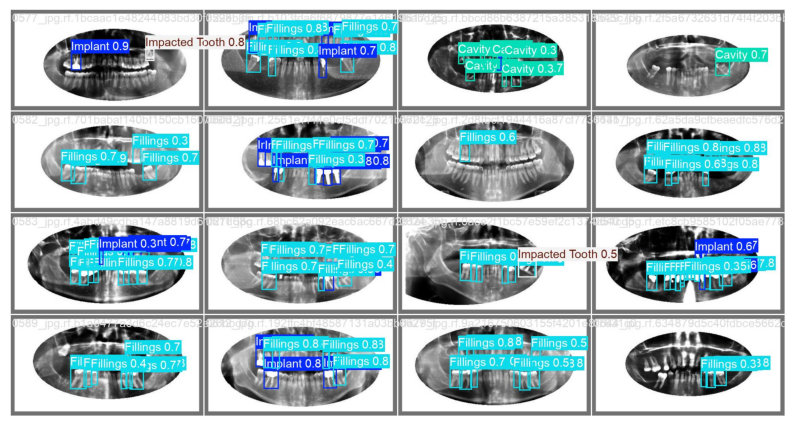

In [15]:
import cv2
import matplotlib.pyplot as plt


image_path = "/kaggle/working/runs/detect/train/val_batch2_pred.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  


plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.show()


In [16]:
# Save Model
model.save("dental_disease_model.h5")

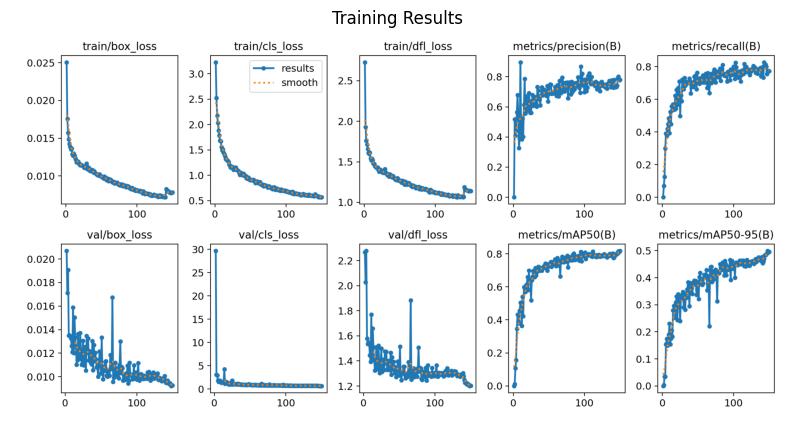

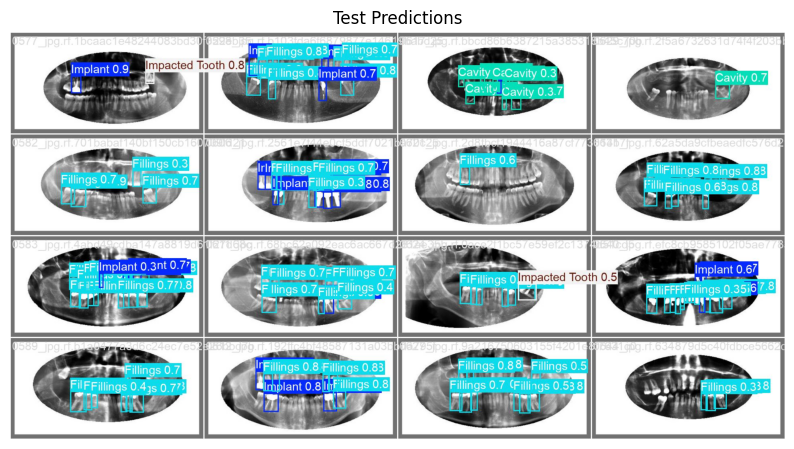

In [22]:
import cv2 as cv
import matplotlib.pyplot as plt

# Display training results
img_path = "runs/detect/train/results.png"
img = cv.imread(img_path)

if img is not None:
    plt.figure(figsize=(10, 10))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Training Results")
    plt.show()
else:
    print(f"Error: Could not load image at {img_path}. Check the file path.")

# Display test results
test_img_path = "runs/detect/train/val_batch2_pred.jpg"
test_img = cv.imread(test_img_path)

if test_img is not None:
    plt.figure(figsize=(10, 10))
    plt.imshow(cv.cvtColor(test_img, cv.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Test Predictions")
    plt.show()
else:
    print(f"Error: Could not load image at {test_img_path}. Check the file path.")


In [25]:
!yolo detect predict source=/kaggle/working/test/images/0128_jpg.rf.717cd6a69102c36ff5b84b4a87c5a210.jpg \
model=runs/detect/train/weights/best.pt \
conf=0.1 iou=0.45 save_txt=True save_conf=True project=runs/detect name=exp4


Ultralytics 8.3.81 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv8x summary (fused): 112 layers, 68,127,420 parameters, 0 gradients, 257.4 GFLOPs

image 1/1 /kaggle/working/test/images/0128_jpg.rf.717cd6a69102c36ff5b84b4a87c5a210.jpg: 320x640 2 Fillingss, 1 Cavity, 68.7ms
Speed: 4.7ms preprocess, 68.7ms inference, 192.9ms postprocess per image at shape (1, 3, 320, 640)
Results saved to runs/detect/exp4
1 label saved to runs/detect/exp4/labels
💡 Learn more at https://docs.ultralytics.com/modes/predict


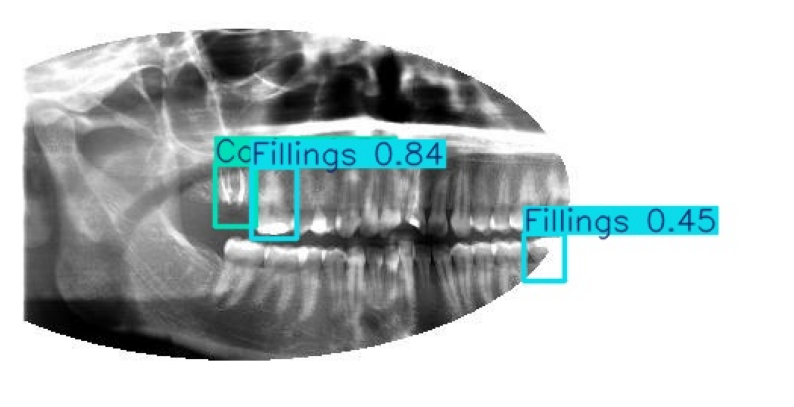

In [27]:
import cv2
import matplotlib.pyplot as plt

# تحميل الصورة بعد التنبؤ
img = cv2.imread("runs/detect/exp4/0128_jpg.rf.717cd6a69102c36ff5b84b4a87c5a210.jpg")

# عرض الصورة
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [33]:
import os
print(os.listdir("/kaggle/working/runs/detect/exp4/"))


['0128_jpg.rf.717cd6a69102c36ff5b84b4a87c5a210.jpg', 'labels']


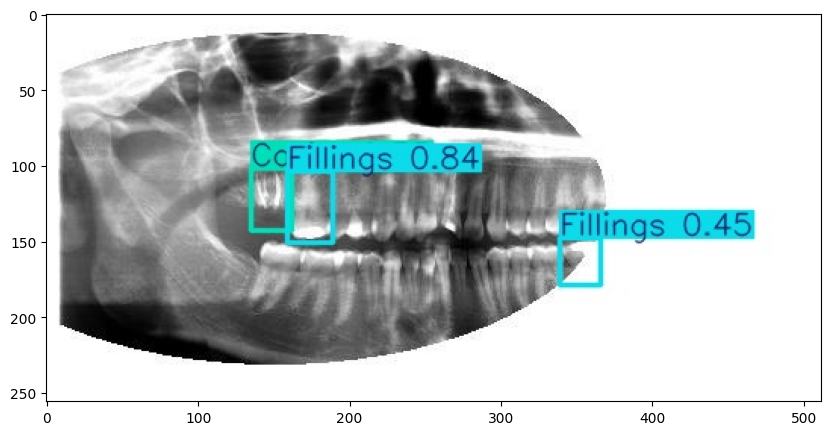

In [34]:
import cv2 as cv
import matplotlib.pyplot as plt

image_path = "/kaggle/working/runs/detect/exp4/0128_jpg.rf.717cd6a69102c36ff5b84b4a87c5a210.jpg"

if os.path.exists(image_path):
    img = cv.imread(image_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.show()
else:
    print("❌ الصورة غير موجودة في المسار المحدد!")


In [48]:
import shutil
import os

source_path = "/kaggle/working/runs/detect/train/weights/best.pt"
destination_folder = "/kaggle/working/best_model"
zip_path = "/kaggle/working/yolov8_100_epochs_model.zip"  # تعديل الاسم لـ YOLOv8

# تأكد من أن المجلد الوجهة موجود
os.makedirs(destination_folder, exist_ok=True)

# نسخ ملف النموذج إلى المجلد الوجهة
shutil.copy(source_path, destination_folder)

# ضغط المجلد الذي يحتوي على النموذج
shutil.make_archive(zip_path.replace(".zip", ""), 'zip', root_dir=destination_folder)

print(f"✅ Model saved as: {zip_path}")


✅ Model saved as: /kaggle/working/yolov8_100_epochs_model.zip
